In [1]:
import numpy as np
import pandas as pd
import os 
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

# Set up plotting style
plt.rcParams.update({'font.size': 12})
sns.set_style("whitegrid")



In [2]:
base_path = "/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results"
eid = "9b528ad0-4599-4a55-9148-96cc1d93fb24" # can be changed based on the session
model = "linear"


results_path = f"{base_path}/{eid}/wheel-speed/{model}/all/{eid}.npy"

# load the data 


In [3]:
# load the data 
data = np.load(results_path, allow_pickle=True).item()
data.keys()



dict_keys(['test_metric', 'test_pred', 'test_y', 'test_prob'])

In [4]:
data['test_pred'][1]


array([ 0.0040935 ,  0.00647716,  0.00487955,  0.00332923,  0.00273983,
        0.00366349,  0.0041192 ,  0.00331236,  0.0026914 ,  0.00328541,
        0.00315617,  0.00298873,  0.00230813,  0.00207766,  0.00219632,
        0.00211149,  0.00163182,  0.00153801,  0.00138462,  0.00103088,
        0.00109591,  0.00130951,  0.00124462,  0.00108143,  0.00019749,
       -0.00032141,  0.00070208,  0.00305869,  0.00581086,  0.00609433,
        0.00480216,  0.00558034,  0.00543302,  0.00642157,  0.02476951,
        0.05259944,  0.08027091,  0.09848123,  0.10959983,  0.11869606,
        0.13340503,  0.15759683,  0.1713288 ,  0.17035148,  0.17177429,
        0.17200731,  0.17945475,  0.18318436,  0.17242945,  0.16275657,
        0.15840734,  0.1524129 ,  0.15568794,  0.15233879,  0.1332852 ,
        0.10674839,  0.10310057,  0.11581745,  0.12529179,  0.11919868,
        0.10358225,  0.08850735,  0.08473458,  0.08748722,  0.08661396,
        0.08541991,  0.07909349,  0.06941042,  0.05878948,  0.05

In [5]:
data['test_y'][1]

array([1.29646922e-03, 1.05296332e-03, 8.97907482e-04, 1.28387131e-03,
       1.11176577e-03, 1.18712814e-03, 1.17273186e-03, 1.16191419e-03,
       1.16670890e-03, 1.18745044e-03, 1.13883303e-03, 1.19398379e-03,
       1.18961890e-03, 4.10294787e-04, 8.98407056e-04, 7.72688984e-04,
       7.99050385e-04, 8.13779270e-04, 7.89739835e-04, 8.07482267e-04,
       7.99384423e-04, 8.00811770e-04, 8.01785993e-04, 8.01152366e-04,
       8.01128775e-04, 7.99858217e-04, 8.05696489e-04, 7.92945826e-04,
       8.10139288e-04, 8.00373376e-04, 7.78472282e-04, 8.61992093e-04,
       7.09658461e-04, 8.42072007e-04, 1.30994866e-03, 2.66647053e-03,
       3.63141480e-03, 8.23409972e-04, 1.75397622e-02, 5.85830959e-02,
       8.21359544e-02, 8.70068502e-02, 8.56303355e-02, 1.02957580e-01,
       2.21907636e-01, 4.11190732e-01, 5.03537826e-01, 4.29687580e-01,
       2.89744030e-01, 1.68630363e-01, 5.13158805e-02, 5.90942042e-02,
       1.38483481e-01, 1.96095513e-01, 2.40394727e-01, 2.65232262e-01,
      

Data shapes: test_y=(68, 100), test_pred=(68, 100)
Flattened shapes: (6800,), (6800,)
Total time points: 6800
.3f
.3f


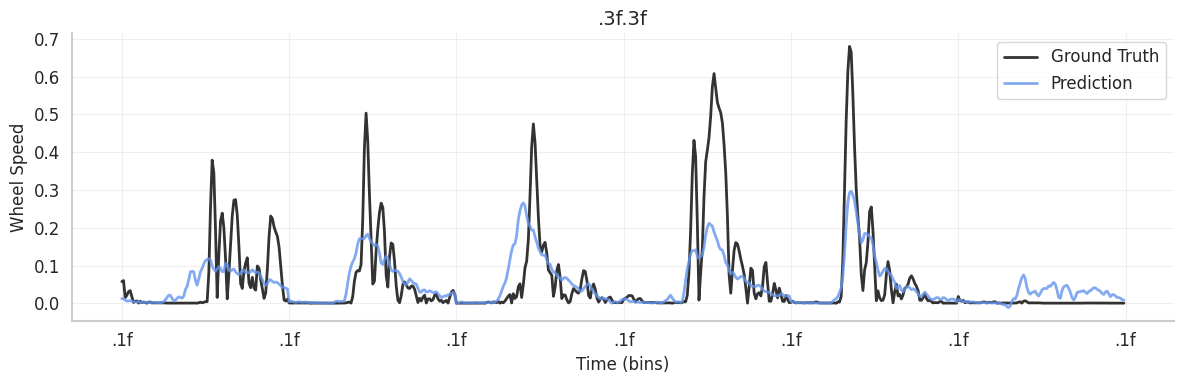

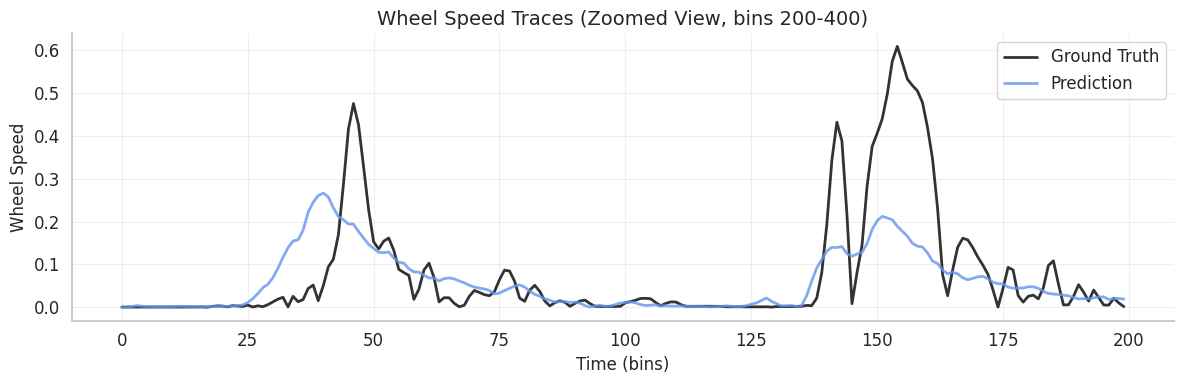

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Load your wheel-speed results
results_path = f"/media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results/{eid}/wheel-speed/linear/all/{eid}.npy"
data = np.load(results_path, allow_pickle=True).item()

# Extract data - already in (63, 100) shape = 63 trials × 100 time bins
test_y = data['test_y']      # Ground truth wheel speed
test_pred = data['test_pred']  # Predicted wheel speed

print(f"Data shapes: test_y={test_y.shape}, test_pred={test_pred.shape}")

# Flatten the data to get continuous time series
# This gives us the wheel speed trace across all trials sequentially
y_flattened = test_y.flatten()      # Ground truth as continuous trace
pred_flattened = test_pred.flatten()  # Predictions as continuous trace

print(f"Flattened shapes: {y_flattened.shape}, {pred_flattened.shape}")
print(f"Total time points: {len(y_flattened)}")

# Calculate performance metrics
correlation = np.corrcoef(y_flattened, pred_flattened)[0, 1]
r2 = r2_score(y_flattened, pred_flattened)
print(".3f")
print(".3f")

# Plot the continuous traces (like in figure_generalization.ipynb)
start_time = 0
end_time = min(600, len(y_flattened))  # Show first 600 time points (~12 seconds at 50Hz)

fig, ax = plt.subplots(1, 1, figsize=(12, 4))

# Plot ground truth (black line, thicker)
ax.plot(y_flattened[start_time:end_time], color="black", linewidth=2, label="Ground Truth", alpha=0.8)

# Plot predictions (colored line)
ax.plot(pred_flattened[start_time:end_time], color="cornflowerblue", linewidth=2, label="Prediction", alpha=0.8)

# Formatting
ax.set_ylabel("Wheel Speed", fontsize=12)
ax.set_xlabel("Time (bins)", fontsize=12)
ax.set_title(".3f"".3f", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5, length=5, labelsize=12)

# Convert x-axis to time in seconds (assuming 50Hz = 0.02s per bin)
xticks = [0, 100, 200, 300, 400, 500, 600]
xticklabels = [".1f" for x in xticks]
ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels)

plt.tight_layout()
plt.savefig('wheel_speed_traces.png', dpi=400, bbox_inches='tight')
plt.show()

# Also show a zoomed-in view of a shorter segment
fig, ax = plt.subplots(1, 1, figsize=(12, 4))
start_zoom = 200  # Start at bin 200
end_zoom = 400    # End at bin 400

ax.plot(y_flattened[start_zoom:end_zoom], color="black", linewidth=2, label="Ground Truth", alpha=0.8)
ax.plot(pred_flattened[start_zoom:end_zoom], color="cornflowerblue", linewidth=2, label="Prediction", alpha=0.8)

ax.set_ylabel("Wheel Speed", fontsize=12)
ax.set_xlabel("Time (bins)", fontsize=12)
ax.set_title(f"Wheel Speed Traces (Zoomed View, bins {start_zoom}-{end_zoom})", fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)

# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)
ax.tick_params(axis='both', width=1.5, length=5, labelsize=12)

plt.tight_layout()
plt.show()

In [3]:
def load_and_plot_wheel_speed_results(results_path, max_trials_to_plot=10, time_bins_per_trial=100):
    """
    Load wheel-speed decoding results and plot target vs prediction traces.
    
    Parameters:
    -----------
    results_path : str
        Path to the .npy results file
    max_trials_to_plot : int
        Maximum number of trials to plot (to avoid overcrowding)
    time_bins_per_trial : int
        Number of time bins per trial (typically 100 for 2-second trials at 50Hz)
    """
    
    # Load the results
    print(f"Loading results from: {results_path}")
    data = np.load(results_path, allow_pickle=True).item()
    
    # Extract data
    test_pred = data['test_pred']  # Predictions
    test_y = data['test_y']        # Ground truth targets
    test_metric = data['test_metric']  # Performance metric (correlation)
    
    print(".3f")
    print(f"Predictions shape: {test_pred.shape}")
    print(f"Targets shape: {test_y.shape}")
    
    # Reshape data to trials × time_bins × features
    # Assuming the data is flattened, we need to reshape it
    if test_pred.ndim == 1:
        # Data is flattened, reshape to (n_trials, time_bins_per_trial, 1)
        n_total_bins = len(test_pred)
        n_trials = n_total_bins // time_bins_per_trial
        
        test_pred_reshaped = test_pred[:n_trials * time_bins_per_trial].reshape(n_trials, time_bins_per_trial, 1)
        test_y_reshaped = test_y[:n_trials * time_bins_per_trial].reshape(n_trials, time_bins_per_trial, 1)
        
        print(f"Reshaped to: {n_trials} trials × {time_bins_per_trial} time bins × 1 feature")
    else:
        # Data is already in the right shape
        test_pred_reshaped = test_pred
        test_y_reshaped = test_y
        n_trials = test_pred_reshaped.shape[0]
    
    # Limit number of trials to plot
    n_trials_to_plot = min(max_trials_to_plot, n_trials)
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Wheel-Speed Decoding Results\nSession: {Path(results_path).stem}', fontsize=16)
    
    # 1. Plot individual trial traces
    ax = axes[0, 0]
    time_axis = np.arange(time_bins_per_trial) * 0.02  # 50Hz = 0.02s per bin
    
    for trial_idx in range(n_trials_to_plot):
        ax.plot(time_axis, test_y_reshaped[trial_idx, :, 0], 
               alpha=0.7, linewidth=1, color='blue', label='Target' if trial_idx == 0 else "")
        ax.plot(time_axis, test_pred_reshaped[trial_idx, :, 0], 
               alpha=0.7, linewidth=1, color='red', label='Prediction' if trial_idx == 0 else "")
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Wheel Speed')
    ax.set_title(f'Individual Trial Traces (showing {n_trials_to_plot} trials)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 2. Plot trial-averaged traces
    ax = axes[0, 1]
    mean_target = np.mean(test_y_reshaped, axis=0)
    mean_pred = np.mean(test_pred_reshaped, axis=0)
    std_target = np.std(test_y_reshaped, axis=0)
    std_pred = np.std(test_pred_reshaped, axis=0)
    
    ax.plot(time_axis, mean_target[:, 0], color='blue', linewidth=2, label='Target (mean)')
    ax.fill_between(time_axis, 
                   mean_target[:, 0] - std_target[:, 0], 
                   mean_target[:, 0] + std_target[:, 0], 
                   alpha=0.3, color='blue')
    
    ax.plot(time_axis, mean_pred[:, 0], color='red', linewidth=2, label='Prediction (mean)')
    ax.fill_between(time_axis, 
                   mean_pred[:, 0] - std_pred[:, 0], 
                   mean_pred[:, 0] + std_pred[:, 0], 
                   alpha=0.3, color='red')
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Wheel Speed')
    ax.set_title('Trial-Averaged Traces (±1 STD)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 3. Scatter plot: predicted vs actual values (flattened)
    ax = axes[1, 0]
    flat_pred = test_pred_reshaped.flatten()
    flat_target = test_y_reshaped.flatten()
    
    # Sample points to avoid overcrowding
    n_samples = min(10000, len(flat_pred))
    sample_idx = np.random.choice(len(flat_pred), n_samples, replace=False)
    
    ax.scatter(flat_target[sample_idx], flat_pred[sample_idx], alpha=0.1, s=1, color='purple')
    
    # Add diagonal line
    min_val = min(flat_target.min(), flat_pred.min())
    max_val = max(flat_target.max(), flat_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', alpha=0.7, label='Perfect prediction')
    
    ax.set_xlabel('Actual Wheel Speed')
    ax.set_ylabel('Predicted Wheel Speed')
    ax.set_title(f'Prediction vs Actual\n(correlation = {test_metric:.3f})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # 4. Residual analysis
    ax = axes[1, 1]
    residuals = flat_target - flat_pred
    
    ax.hist(residuals, bins=50, alpha=0.7, color='orange', density=True)
    ax.axvline(x=0, color='black', linestyle='--', alpha=0.7)
    ax.set_xlabel('Residual (Actual - Predicted)')
    ax.set_ylabel('Density')
    ax.set_title(f'Residual Distribution\n(mean = {residuals.mean():.3f}, std = {residuals.std():.3f})')
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{Path(results_path).stem}_wheel_speed_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print some statistics
    print("\n=== Statistics ===")
    print(f"Number of trials: {n_trials}")
    print(f"Time bins per trial: {time_bins_per_trial}")
    print(".3f")
    print(".3f")
    print(".3f")
    
    # Check for any obvious issues
    if test_metric < 0:
        print("⚠️  WARNING: Negative correlation detected!")
    elif test_metric < 0.1:
        print("⚠️  WARNING: Very low correlation!")
    else:
        print("✓ Correlation looks reasonable")
    
    pred_range = flat_pred.max() - flat_pred.min()
    target_range = flat_target.max() - flat_target.min()
    print(".3f")
    print(".3f")

   

Loading results from: /media/lenny-aharon/T7/ibl-mouse/ibl-mouse_neural-activity/results/5c0c560e-9e1f-45e9-b66e-e4ee7855be84/wheel-speed/linear/all/5c0c560e-9e1f-45e9-b66e-e4ee7855be84.npy
.3f
Predictions shape: (63, 100)
Targets shape: (63, 100)


IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

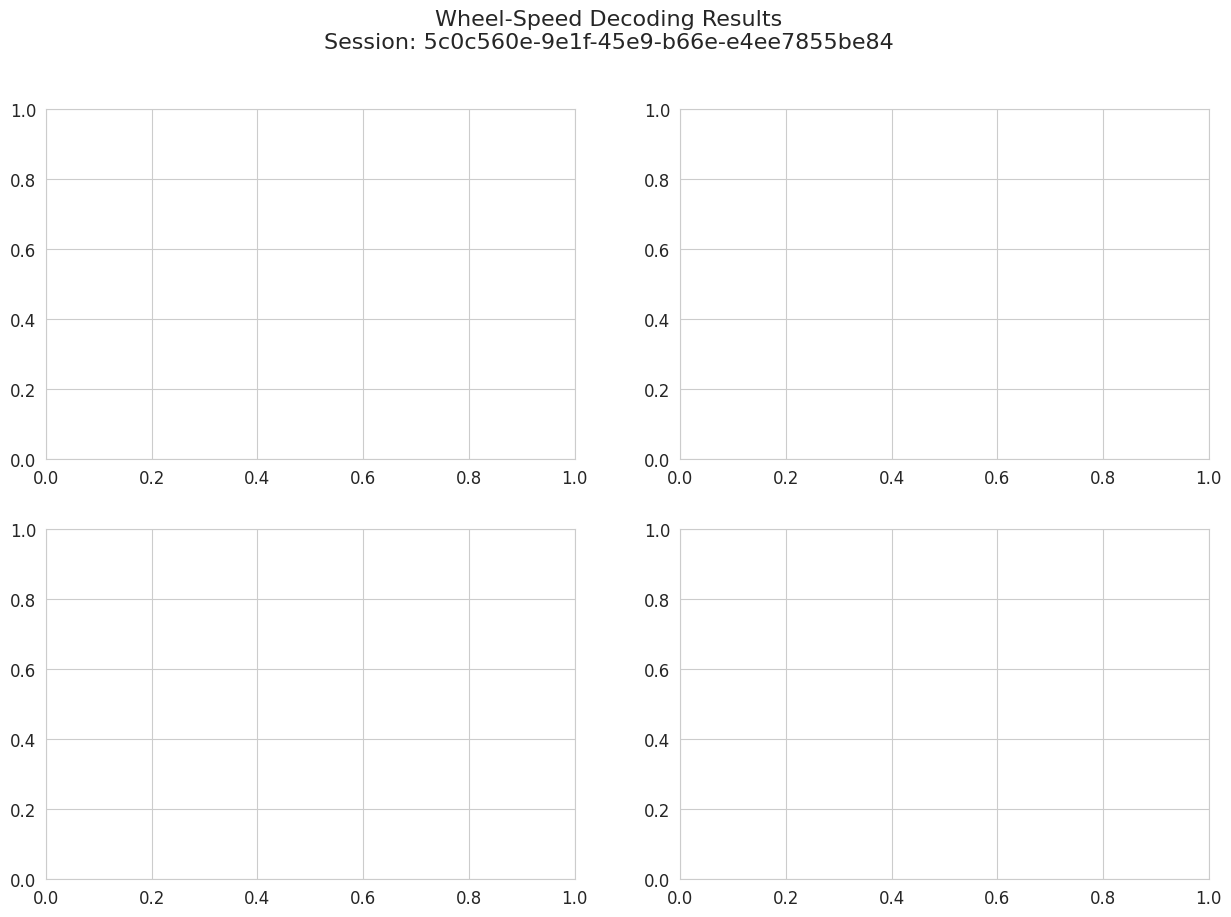

In [4]:
  
# Load and plot the results
load_and_plot_wheel_speed_results(results_path)